In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [2]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

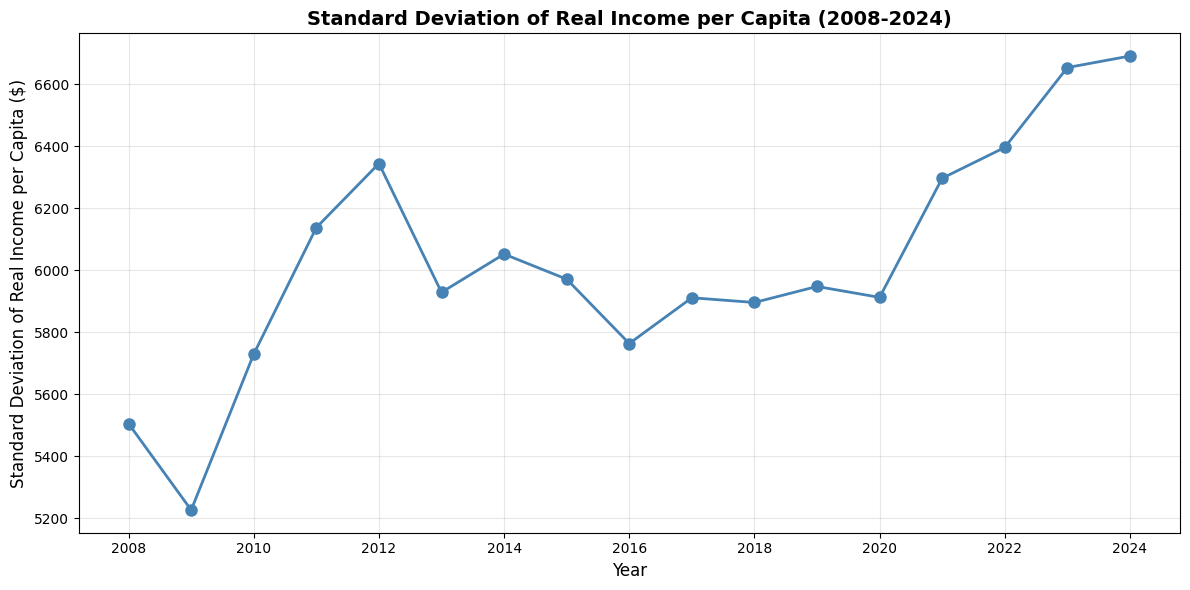

year
2008    5504.888992
2009    5226.389746
2010    5729.447855
2011    6137.219143
2012    6343.851191
2013    5928.358361
2014    6051.780052
2015    5970.813592
2016    5763.384436
2017    5910.891820
2018    5895.667169
2019    5947.329981
2020    5912.120793
2021    6296.345517
2022    6395.653223
2023    6653.265112
2024    6690.435537
Name: real_income_pc, dtype: float64


In [3]:
# Filter for years 2008-2024
df_filtered = df[(df['year'] >= 2008) & (df['year'] <= 2024)].copy()

# Calculate standard deviation of real income by year
std_by_year = df_filtered.groupby('year')['real_income_pc'].std()

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(std_by_year.index, std_by_year.values, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Standard Deviation of Real Income per Capita ($)', fontsize=12)
plt.title('Standard Deviation of Real Income per Capita (2008-2024)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(std_by_year)

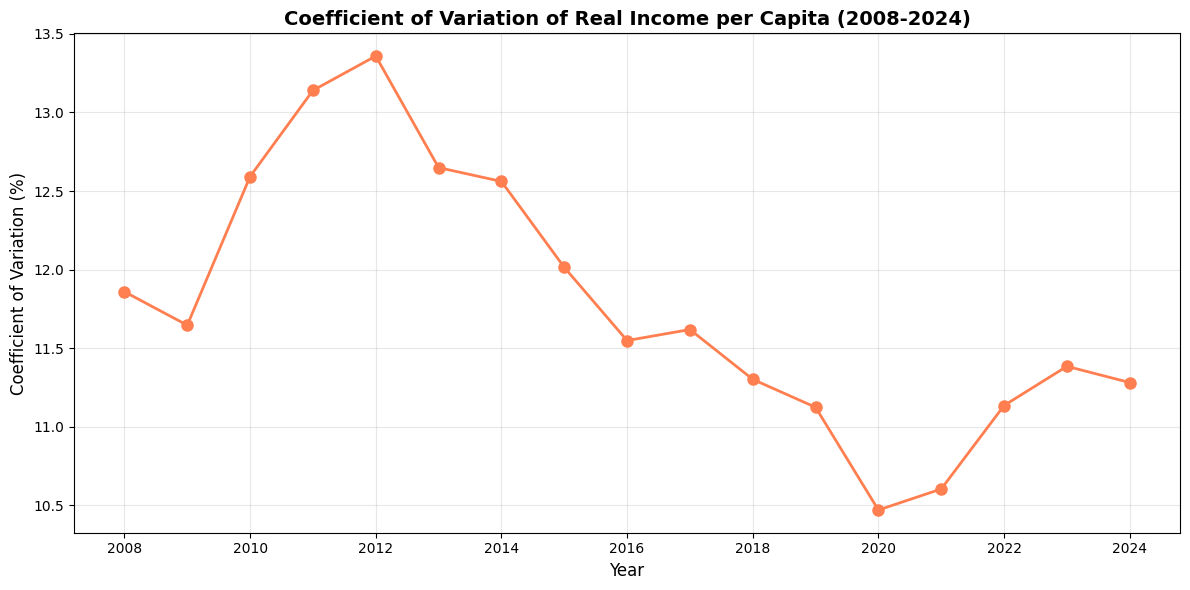

year
2008    11.858693
2009    11.645518
2010    12.592085
2011    13.140418
2012    13.359496
2013    12.649186
2014    12.560941
2015    12.013970
2016    11.547600
2017    11.617950
2018    11.300753
2019    11.122676
2020    10.468497
2021    10.602467
2022    11.134057
2023    11.383599
2024    11.280287
Name: real_income_pc, dtype: float64


In [4]:
# Calculate coefficient of variation by year
cv_by_year = (df_filtered.groupby('year')['real_income_pc'].std() / df_filtered.groupby('year')['real_income_pc'].mean()) * 100

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(cv_by_year.index, cv_by_year.values, marker='o', linewidth=2, markersize=8, color='coral')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Coefficient of Variation (%)', fontsize=12)
plt.title('Coefficient of Variation of Real Income per Capita (2008-2024)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(cv_by_year)

In [5]:
# Compute percent change from 2008 to 2024
std_2008 = std_by_year[2008]
std_2024 = std_by_year[2024]
std_pct_change = ((std_2024 - std_2008) / std_2008) * 100

cv_2008 = cv_by_year[2008]
cv_2024 = cv_by_year[2024]
cv_pct_change = ((cv_2024 - cv_2008) / cv_2008) * 100

print("Percent Change (2008-2024):")
print(f"Standard Deviation: {std_pct_change:.2f}%")
print(f"  2008: ${std_2008:.2f}")
print(f"  2024: ${std_2024:.2f}")
print()
print(f"Coefficient of Variation: {cv_pct_change:.2f}%")
print(f"  2008: {cv_2008:.2f}%")
print(f"  2024: {cv_2024:.2f}%")

Percent Change (2008-2024):
Standard Deviation: 21.54%
  2008: $5504.89
  2024: $6690.44

Coefficient of Variation: -4.88%
  2008: 11.86%
  2024: 11.28%
